# 02 — Well State Detection

**Goals**
- Q2: characterise acceleration when running vs stopped; detect state
- Q3: classify controller mode (continuous / timer / shutdown)
- Q4: estimate runtime fraction (excluding >12 h shutdowns)

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from well_analysis.data import load_test_data
from well_analysis.signal import check_even_sampling
from well_analysis.detection import detect_well_state, classify_controller_mode
from well_analysis.viz import plot_time_series, plot_well_state

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

df = load_test_data()
_, fs = check_even_sampling(df['Timestamp'])
print(f"fs = {fs:.2f} Hz")

fs = 10.00 Hz


## 1. What to expect: running vs stopped (Q2)

- **Stopped**: rod is stationary → acceleration ≈ constant (gravity + sensor offset, ≈ −9.81 m/s²).
- **Running**: rod oscillates at the pump frequency (0.05–0.1 Hz) → acceleration varies periodically.

→ **Method**: compute the rolling RMS of the AC component (signal minus its median). High RMS = running; near-zero RMS = stopped. O(n) via `scipy.ndimage.uniform_filter1d`.

In [2]:
accel = df['Acceleration'].values
is_running = detect_well_state(accel, fs=fs)

print(f"Fraction running (raw): {is_running.mean():.3f}")

Fraction running (raw): 0.111


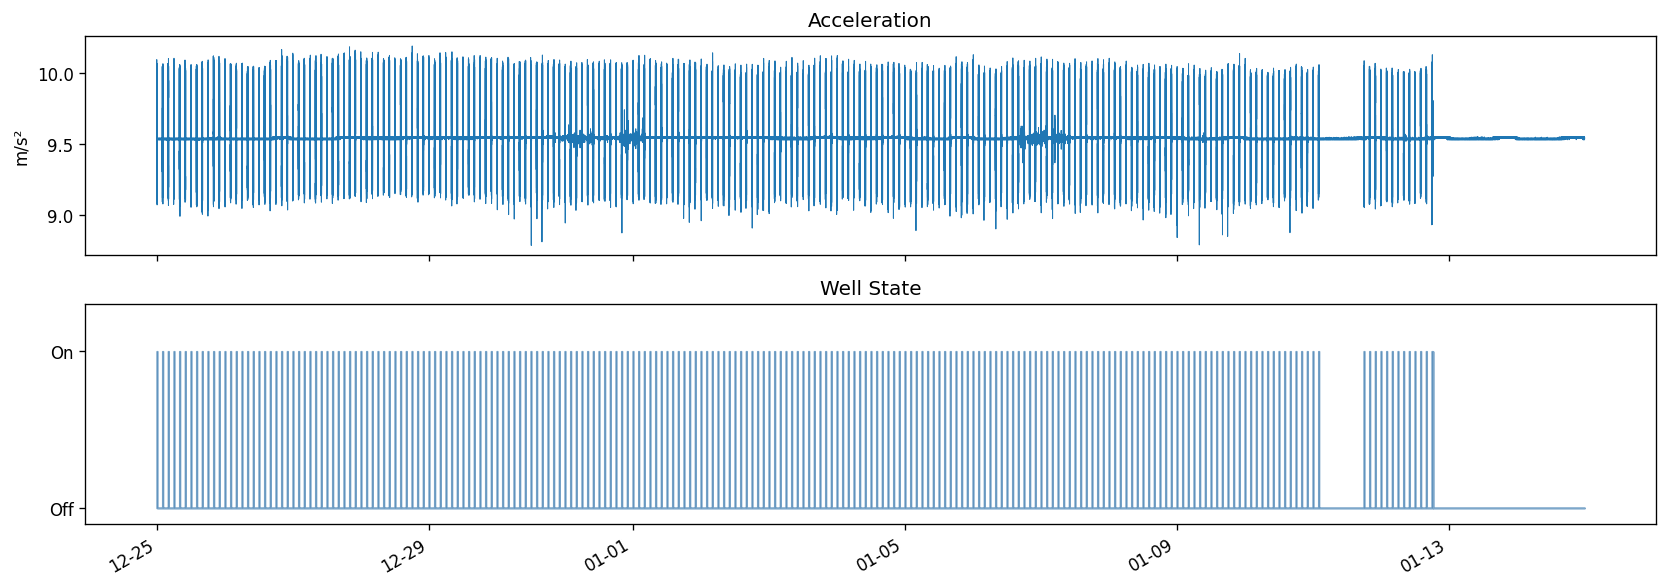

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
plot_time_series(df['Timestamp'], accel, ylabel='m/s²',
                 title='Acceleration', ax=axes[0])
plot_well_state(df['Timestamp'], is_running, ax=axes[1])
plt.tight_layout()
plt.show()

## 2. Controller mode classification (Q3)

In [4]:
segments = classify_controller_mode(df['Timestamp'], is_running)
print(segments['mode'].value_counts())
segments.head(20)

mode
timer_off    216
timer_on     216
running        4
off            2
shutdown       2
Name: count, dtype: int64


,start,end,running,duration_h,mode
0,2020-12-25 00:00:00.165876124+00:00,2020-12-25 00:15:11.565876124+00:00,True,0.253167,running
1,2020-12-25 00:15:11.665876124+00:00,2020-12-25 01:59:53.565876124+00:00,False,1.744972,timer_off
2,2020-12-25 01:59:53.665876124+00:00,2020-12-25 02:15:12.065876124+00:00,True,0.255111,timer_on
3,2020-12-25 02:15:12.165876124+00:00,2020-12-25 03:59:53.565876124+00:00,False,1.744833,timer_off
4,2020-12-25 03:59:53.665876124+00:00,2020-12-25 04:15:13.165876124+00:00,True,0.255417,timer_on
5,2020-12-25 04:15:13.265876124+00:00,2020-12-25 05:59:53.965876124+00:00,False,1.744639,timer_off
6,2020-12-25 05:59:54.065876124+00:00,2020-12-25 06:15:12.665876124+00:00,True,0.255167,timer_on
7,2020-12-25 06:15:12.765876124+00:00,2020-12-25 07:59:53.765876124+00:00,False,1.744722,timer_off
8,2020-12-25 07:59:53.865876124+00:00,2020-12-25 08:15:13.265876124+00:00,True,0.255389,timer_on
9,2020-12-25 08:15:13.365876124+00:00,2020-12-25 09:59:53.865876124+00:00,False,1.744583,timer_off


## 3. Runtime fraction — excluding long shutdowns (Q4)

In [5]:
# Exclude segments where the well was down > 12 h
shutdown_mask = (segments['mode'] == 'shutdown')
excluded_time_h = segments.loc[shutdown_mask, 'duration_h'].sum()

total_h = (df['Timestamp'].iloc[-1] - df['Timestamp'].iloc[0]).total_seconds() / 3600
active_h = total_h - excluded_time_h

running_h = segments.loc[segments['running'] == True, 'duration_h'].sum()
runtime_fraction = running_h / active_h

print(f"Total span          : {total_h:.1f} h")
print(f"Excluded (shutdown) : {excluded_time_h:.1f} h")
print(f"Active window       : {active_h:.1f} h")
print(f"Running time        : {running_h:.1f} h")
print(f"Runtime fraction    : {runtime_fraction:.3f}  ({runtime_fraction*100:.1f} %)")

Total span          : 504.0 h
Excluded (shutdown) : 69.2 h
Active window       : 434.8 h
Running time        : 55.8 h
Runtime fraction    : 0.128  (12.8 %)


---
# Robust extensions (§ 4–§ 8)

The cells above are the **basic version** that answers Q2/Q3/Q4 with simple
defaults. Below we audit the basic version's hidden assumptions, scan for an
optimal window length, replace the timer test with a parameter-free one, and
extend the detector to a sliding-threshold mode.

Each section can be skipped independently of the others.

## 4. Are the basic assumptions actually true?

The basic detector silently relies on:
- (a) stopped ⇒ accel ≈ constant
- (b) running RMS ≫ stopped RMS
- (g) RMS histogram is bimodal (so Otsu/valley split is meaningful)

If any fails the basic threshold is unreliable. Test by inspecting the RMS
histogram directly (log y so the small running peak is visible).

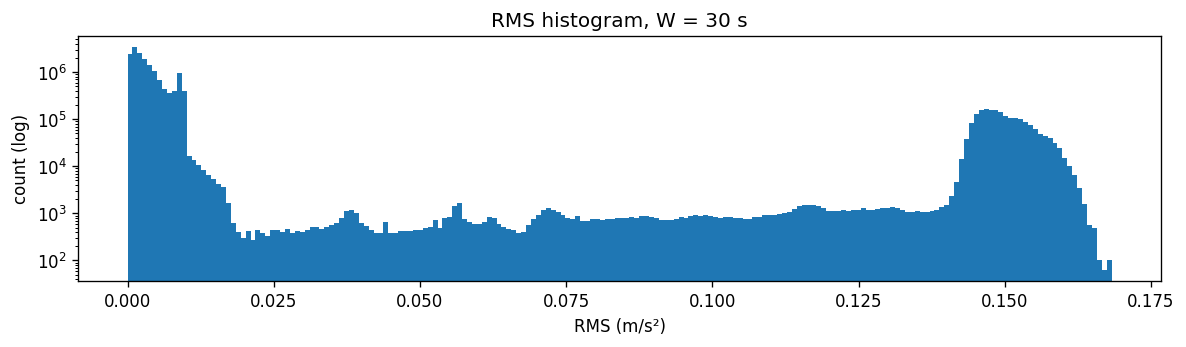

#significant peaks: 2  at RMS = [0.0013 0.1468]


In [6]:
from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks

ac = accel - np.median(accel)
rms30 = np.sqrt(np.maximum(0.0, uniform_filter1d(ac**2, size=int(30*fs))))

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(rms30, bins=200); ax.set_yscale('log')
ax.set_xlabel('RMS (m/s²)'); ax.set_ylabel('count (log)')
ax.set_title('RMS histogram, W = 30 s')
plt.tight_layout(); plt.show()

counts, edges = np.histogram(rms30, bins=200)
centers = 0.5*(edges[:-1] + edges[1:])
peaks, _ = find_peaks(counts, distance=10, prominence=counts.max()*0.001)
print(f'#significant peaks: {len(peaks)}  at RMS = {centers[peaks].round(4)}')

## 5. Gravity offset: full-data vs stopped-only median

`detect_well_state` removes the DC component using `np.median(accel)` over the
WHOLE signal. That's only correct if stopped samples dominate. Quantify the bias.

In [7]:
g_full    = float(np.median(accel))
g_stopped = float(np.median(accel[~is_running]))
g_running = float(np.median(accel[is_running]))
print(f'median(all)     = {g_full:.6f}')
print(f'median(stopped) = {g_stopped:.6f}  <-- true gravity offset for downstream integration')
print(f'median(running) = {g_running:.6f}')
print(f'bias |full - stopped| = {abs(g_full - g_stopped):.2e}')

median(all)     = 9.539297
median(stopped) = 9.539297  <-- true gravity offset for downstream integration
median(running) = 9.493232
bias |full - stopped| = 0.00e+00


## 6. Window scan — is W = 30 s really optimal?

Scan W from 1 s to 600 s and score each by 4 separation metrics:

- **BC**: bimodality coefficient (Pearson). >0.555 ⇒ bimodal.
- **Otsu σ²_between**: max inter-class variance.
- **Valley depth**: 1 − valley/min(peaks). Closer to 1 = deeper valley.
- **KL(N₀||N₁)**: KL between two Gaussians fit on either side of Otsu threshold.

Physical intuition (revised): smaller W is noisier within a class but sharper at
on/off edges. With 232 timer cycles in this dataset there are ~464 edges, so
edge-bleeding (large W) typically dominates the within-class noise (small W).

    W_s      BC    Otsu  Valley        KL     thr
0     1  0.9290  0.0019  0.9885    9.4479  0.0809
1     2  0.9413  0.0020  0.9976   10.2975  0.0745
2     3  0.9612  0.0020  0.9983   20.9217  0.0755
3     5  0.9847  0.0021  0.9989   80.9979  0.0756
4    10  0.9921  0.0021  0.9992  209.7268  0.0759
5    15  0.9915  0.0021  0.9990  152.2823  0.0762
6    20  0.9918  0.0021  0.9988  153.7946  0.0757
7    30  0.9908  0.0021  0.9983  125.5889  0.0759
8    45  0.9893  0.0021  0.9978   89.2489  0.0750
9    60  0.9878  0.0021  0.9958   68.1821  0.0748
10   90  0.9847  0.0020  0.9950   48.2390  0.0741
11  120  0.9816  0.0020  0.9940   36.7741  0.0731
12  180  0.9753  0.0020  0.9935   26.0226  0.0716
13  240  0.9690  0.0020  0.9929   20.5207  0.0704
14  300  0.9628  0.0019  0.9920   17.0519  0.0690
15  450  0.9475  0.0019  0.9856   12.5551  0.0656
16  600  0.9333  0.0018  0.9776   10.5257  0.0624


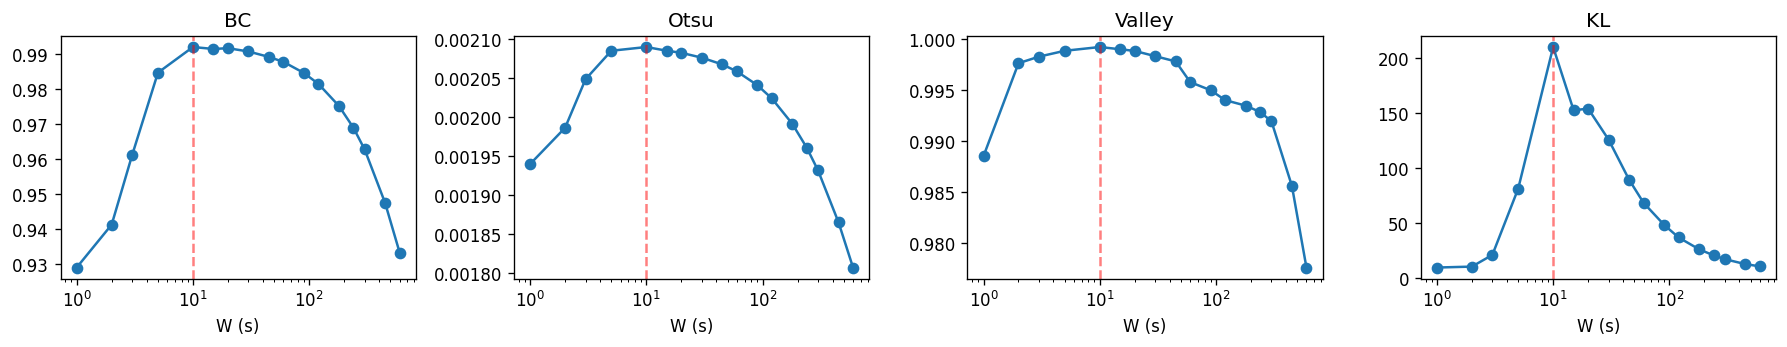


Best W per metric: {'BC': 10, 'Otsu': 10, 'Valley': 10, 'KL': 10}


In [8]:
from scipy import stats

def rolling_rms(x, W):
    return np.sqrt(np.maximum(0.0, uniform_filter1d(x**2, size=W)))

def bimodality_coefficient(x):
    n = len(x)
    g1 = stats.skew(x); g2 = stats.kurtosis(x, fisher=False) - 3
    return (g1**2 + 1) / (g2 + 3*(n-1)**2/((n-2)*(n-3)))

def otsu_sigma2(x, bins=256):
    counts, edges = np.histogram(x, bins=bins); p = counts/counts.sum()
    centers = 0.5*(edges[:-1]+edges[1:])
    omega = np.cumsum(p); mu = np.cumsum(p*centers); mu_T = mu[-1]
    with np.errstate(divide='ignore', invalid='ignore'):
        s2b = (mu_T*omega - mu)**2 / (omega*(1-omega))
    s2b = np.nan_to_num(s2b)
    k = int(np.argmax(s2b)); return float(s2b[k]), float(centers[k])

def valley_depth(x, bins=256):
    counts, edges = np.histogram(x, bins=bins)
    peaks, _ = find_peaks(counts, distance=10, prominence=counts.max()*0.001)
    if len(peaks) < 2: return 0.0
    p1, p2 = peaks[0], peaks[-1]
    return 1.0 - counts[p1:p2].min()/min(counts[p1], counts[p2])

def kl_two_gauss(x, threshold):
    a = x[x <= threshold]; b = x[x > threshold]
    if len(a) < 10 or len(b) < 10: return 0.0
    m0, s0 = a.mean(), a.std()+1e-9; m1, s1 = b.mean(), b.std()+1e-9
    return float(np.log(s1/s0) + (s0**2 + (m0-m1)**2)/(2*s1**2) - 0.5)

windows_s = [1, 2, 3, 5, 10, 15, 20, 30, 45, 60, 90, 120, 180, 240, 300, 450, 600]
scan_rows = []
for W_s in windows_s:
    r = rolling_rms(ac, max(1, int(W_s*fs)))
    bc = bimodality_coefficient(r[::100])
    s2b, thr = otsu_sigma2(r); vd = valley_depth(r); kl = kl_two_gauss(r, thr)
    scan_rows.append(dict(W_s=W_s, BC=bc, Otsu=s2b, Valley=vd, KL=kl, thr=thr))
scan = pd.DataFrame(scan_rows)
print(scan.round(4))

fig, axes = plt.subplots(1, 4, figsize=(15, 3))
for ax, col in zip(axes, ['BC','Otsu','Valley','KL']):
    ax.plot(scan['W_s'], scan[col], 'o-')
    ax.set_xscale('log'); ax.set_xlabel('W (s)'); ax.set_title(col)
    best = int(scan.loc[scan[col].idxmax(), 'W_s'])
    ax.axvline(best, color='r', ls='--', alpha=0.5)
plt.tight_layout(); plt.show()
print('\nBest W per metric:', {col: int(scan.loc[scan[col].idxmax(), 'W_s']) for col in ['BC','Otsu','Valley','KL']})

## 7. Mode clustering + timer regularity (parameter-free)

The basic `classify_controller_mode` rule "running between two off → timer_on"
does not validate segment durations. As a result it promotes 1-second flickers
to "timer_on", inflating the apparent timer-cycle CV.

Instead, **first cluster all segments by their duration (in log space)** — the
data shows clean 0.5+ log gaps between physical modes (timer / shutdown /
boundary noise), so any 1-D agglomerative clustering with threshold ≈ 0.4
recovers the same partition.

Then a *valid timer cycle* is any consecutive triple
`timer_on → timer_off → timer_on`. Cycle CV is computed only over those —
no thresholds, no outlier filter.

In [9]:
from well_analysis.detection import cluster_segments_by_duration, validate_timer_regularity

seg_clust, cluster_summary = cluster_segments_by_duration(segments)
print('=== Cluster summary ===')
print(cluster_summary.to_string(index=False))

=== Cluster summary ===
 cluster  running   n  median_dur_s  min_dur_s  max_dur_s     label
       0     True   1          20.5       20.5       20.5 noise_run
       1     True 219         919.5      864.4      925.2  timer_on
       2    False   1         848.1      848.1      848.1 other_off
       3    False 217        6280.3     6275.1     6337.1 timer_off
       4    False   1       56679.9    56679.9    56679.9  shutdown
       5    False   1      192580.1   192580.1   192580.1  shutdown


In [10]:
result = validate_timer_regularity(seg_clust)
print('=== Timer regularity (parameter-free) ===')
for k, v in result.items():
    print(f'  {k:25s}: {v}')

=== Timer regularity (parameter-free) ===
  n_segments_timer_on      : 219
  n_valid_cycles           : 217
  mean_cycle_min           : 120.00201996927802
  std_cycle_min            : 0.09567946632956949
  cv                       : 0.0007973154648068807
  is_true_timer            : True


## 8. Sliding-threshold detector — robustness over long deployments

A single global Otsu threshold is fine when the sensor calibration is stable
over the whole 21 days. For longer deployments or noisier sensors, threshold
drift can become an issue. `detect_well_state` accepts an optional
`chunk_hours=` argument that recomputes Otsu within each chunk, with a
**bimodality gate**: a chunk's local Otsu is used only if its
between-class variance is at least 30 % of the global between-class variance,
otherwise the global threshold is used (prevents shredding all-stopped chunks
during shutdowns).

In [11]:
is_running_slide = detect_well_state(accel, fs=fs, chunk_hours=24)
seg_slide        = classify_controller_mode(df['Timestamp'], is_running_slide)
seg_slide_c, _   = cluster_segments_by_duration(seg_slide)
v_slide          = validate_timer_regularity(seg_slide_c)

total_h = (df['Timestamp'].iloc[-1] - df['Timestamp'].iloc[0]).total_seconds() / 3600

def runtime_fraction(seg, total_h):
    ex  = seg.loc[seg['mode']=='shutdown', 'duration_h'].sum()
    run = seg.loc[seg['running']==True,  'duration_h'].sum()
    return run/(total_h - ex), ex, run

rf_g, ex_g, run_g = runtime_fraction(segments,   total_h)
rf_s, ex_s, run_s = runtime_fraction(seg_slide,  total_h)

print(f'GLOBAL  : excluded={ex_g:5.1f} h  running={run_g:5.1f} h  fraction={rf_g*100:5.2f}%')
print(f'SLIDING : excluded={ex_s:5.1f} h  running={run_s:5.1f} h  fraction={rf_s*100:5.2f}%')
diff = (is_running_slide != is_running).sum()
print(f'Δ samples flipped: {diff:,} ({diff/len(is_running_slide)*100:.3f}%)')
print(f'Sliding timer CV: {v_slide.get("cv", "n/a"):.5f}')

GLOBAL  : excluded= 69.2 h  running= 55.8 h  fraction=12.84%
SLIDING : excluded= 69.2 h  running= 55.8 h  fraction=12.84%
Δ samples flipped: 1,267 (0.007%)
Sliding timer CV: 0.00080


/Users/wrg/well-analysis/notebooks/../src/well_analysis/detection/well_state.py:139: RuntimeWarning: divide by zero encountered in log10
  log_d = np.log10(durs_s)
